In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
import seaborn as sns
import os
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
import tensorflow as tf
# use tf.keras submodules via the already-imported tensorflow to avoid linter issues
layers = tf.keras.layers
models = tf.keras.models
callbacks = tf.keras.callbacks
import warnings
warnings.filterwarnings('ignore')

In [423]:
dof1_force = np.load("dummy_ninapro_data\dof1_forces.npy")
dof1_labels = np.load("dummy_ninapro_data\dof1_labels.npy")
dof1_signals = np.load("dummy_ninapro_data\dof1_signals.npy")
mvc_signals = np.load("dummy_ninapro_data\mvc_signals.npy")
mvc_labels = np.load("dummy_ninapro_data\mvc_labels.npy")
mvc_values = np.load("dummy_ninapro_data\mvc_values.npy")
ndof_signals = np.load("dummy_ninapro_data\\ndof_signals.npy")
ndof_labels = np.load("dummy_ninapro_data\\ndof_labels.npy")
ndof_combo_map = np.load("dummy_ninapro_data\\ndof_combo_map.npy", allow_pickle=True)
pr_signals = np.load("dummy_ninapro_data\\pr_signals.npy")
pr_labels = np.load("dummy_ninapro_data\\pr_labels.npy")


<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
C:\Users\vin1\AppData\Local\Temp\ipykernel_2080\543196072.py:1: SyntaxWarning: invalid escape sequence '\d'
  dof1_force = np.load("dummy_ninapro_data\dof1_forces.npy")
C:\Users\vin1\AppData\Local\Temp\ipykernel_2080\543196072.py:2: SyntaxWarning: invalid escape sequence '\d'
  dof1_labels = np.load("dummy_ninapro_data\dof1_labels.npy")
C:\Users\vin1\AppData\Local\Temp\ipykernel_2080\543196072.py:

In [424]:
sample = pr_signals[1]

print("Min:", sample.min())
print("Max:", sample.max())
print("Std:", sample.std())

Min: -1.525631949636497
Max: 1.5923041271036855
Std: 0.38460353411738635


In [425]:
sample = pr_signals[1]  # shape (200, 14)

df = pd.DataFrame(sample)

print(df.head(16))


          0         1         2         3         4         5         6   \
0  -0.079624  0.378916  0.165265 -0.117591 -0.497178  0.173912 -0.333516   
1  -0.116854  0.371965 -0.200735  0.130623 -0.366407  0.404900 -0.483994   
2   0.793244  0.454406 -0.290922  0.080218 -0.593471  0.194342  0.243107   
3   0.224785  0.446026  0.214965 -0.648306 -0.934859  0.485212 -0.626266   
4   0.810952  0.332056 -0.016147 -0.288917 -0.829383  0.340833 -0.242061   
5   0.243597  0.210094  0.271149 -0.277290 -0.435544  0.287984 -0.310505   
6  -0.316474  0.412560 -0.276021 -0.550991 -0.569694  0.123123 -0.347453   
7   0.064573  0.407298 -0.331283 -0.611104 -1.181901 -0.124255 -0.771923   
8   0.139062  0.108815 -0.426653 -0.952826 -0.312550  0.353878 -0.515843   
9   0.386216  0.850599 -0.560152 -0.375693 -1.001321  0.217779 -0.429783   
10  0.434206  0.625518  0.158841  0.046314 -0.778642  0.496930 -0.626317   
11  0.256857  0.379498 -0.385544 -0.296230  0.089135 -0.450487  0.124398   
12 -0.629168

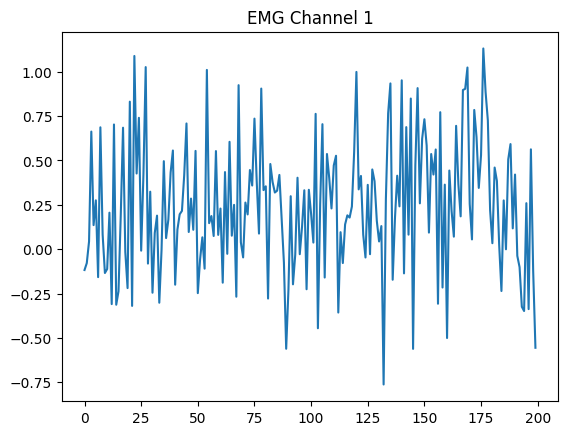

In [426]:
plt.plot(pr_signals[2][:, 3:4])  # EMG channel 1
plt.title("EMG Channel 1")
plt.show()

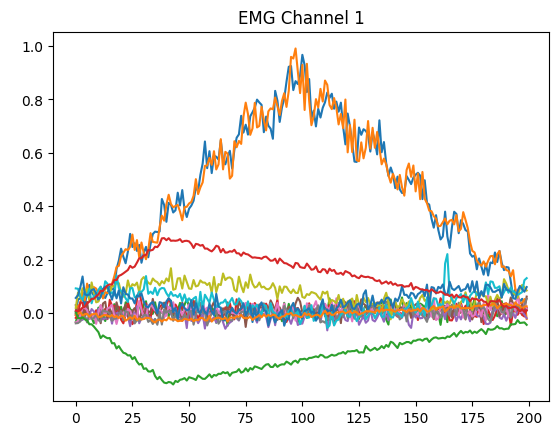

In [427]:
plt.plot(dof1_signals[3])  # EMG channel 1
plt.title("EMG Channel 1")
plt.show()

In [428]:
print("Signals shape:", mvc_signals.shape)
print("Labels shape:", mvc_labels.shape)
print("Unique gesture classes:", np.unique(mvc_labels))
print("Data type:", mvc_signals.dtype)

Signals shape: (250, 200, 14)
Labels shape: (250,)
Unique gesture classes: [0 1 2 3 4]
Data type: float64


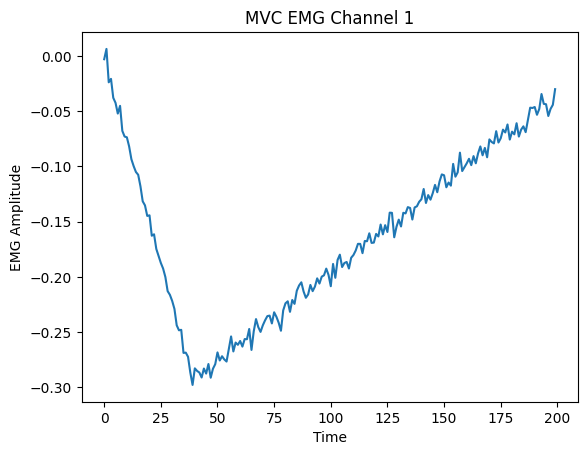

In [429]:
plt.plot(mvc_signals[0][:, 13])  # EMG channel 1
plt.title("MVC EMG Channel 1")
plt.xlabel("Time")
plt.ylabel("EMG Amplitude")
plt.show()

In [430]:
def extract_features(window):
    # window shape: (200, 14)
    
    # RMS — square every value, take mean across time, then square root
    # axis=0 means we compute along the time axis, giving one value per channel
    rms = np.sqrt(np.mean(window**2, axis=0))        # shape: (14,)
    
    # MAV — absolute value of every sample, then mean across time
    mav = np.mean(np.abs(window), axis=0)             # shape: (14,)
    
    # ZC — check where consecutive samples have opposite signs
    # multiplying adjacent samples: if signs differ, product is negative
    # so we count where the product is less than zero
    zc = np.sum(window[:-1] * window[1:] < 0, axis=0) # shape: (14,)
    
    # WL — absolute difference between consecutive samples, summed across time
    wl = np.sum(np.abs(np.diff(window, axis=0)), axis=0) # shape: (14,)

    return np.concatenate([rms, mav, zc, wl])

In [431]:
X = np.array([extract_features(mvc_signals[i]) for i in range(len(mvc_signals))])
y = mvc_labels

print("Feature matrix shape:", X.shape)  # should be (250, 56)
print("Labels shape:", y.shape)           # should be (250,)

Feature matrix shape: (250, 56)
Labels shape: (250,)


In [432]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [433]:
x_train_df = pd.DataFrame(X_train, columns=[f"rms_ch{i+1}" for i in range(14)] +
                                  [f"mav_ch{i+1}" for i in range(14)] +
                                  [f"zc_ch{i+1}" for i in range(14)] +
                                  [f"wl_ch{i+1}" for i in range(14)])
x_train_df['label'] = y_train
x_train_df 

,rms_ch1,rms_ch2,rms_ch3,rms_ch4,rms_ch5,rms_ch6,rms_ch7,rms_ch8,rms_ch9,rms_ch10,...,wl_ch6,wl_ch7,wl_ch8,wl_ch9,wl_ch10,wl_ch11,wl_ch12,wl_ch13,wl_ch14,label
0,0.351739,0.609426,0.575366,0.378286,0.035948,0.031038,0.034276,0.031122,0.458252,0.162962,...,6.259419,7.098597,6.819838,4.723757,4.716003,4.231543,1.188575,1.392142,1.427204,1
1,0.737388,0.651753,0.295392,0.036008,0.033537,0.032063,0.033419,0.031426,0.077130,0.060026,...,7.225877,6.596923,6.560110,4.629556,4.448418,4.865195,1.423282,1.378394,1.310695,0
2,0.033799,0.566011,0.877211,0.789991,0.524877,0.038162,0.039546,0.037388,0.815383,0.139165,...,6.464085,6.498776,6.208350,4.061261,4.706610,4.520725,1.435827,1.422606,1.339723,2
3,0.238955,0.463438,0.395127,0.304091,0.033576,0.034122,0.028457,0.031080,0.536791,0.206502,...,6.295310,6.097757,6.518719,5.246635,4.193276,4.457652,1.450729,1.462309,1.425383,1
4,0.670758,1.031402,1.033567,0.650388,0.028256,0.033743,0.040360,0.031314,0.487679,0.185109,...,5.945126,7.209150,6.375563,4.748167,4.242254,4.664239,1.347754,1.234042,1.304399,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,0.031906,0.190021,0.373448,0.401280,0.310807,0.037195,0.041032,0.035288,0.818169,0.095065,...,7.569898,6.185419,6.843987,4.895246,5.334748,4.349928,1.295313,1.438371,1.420121,2
196,0.572248,0.552973,0.276633,0.033011,0.037881,0.041579,0.038587,0.034032,0.110856,0.056291,...,6.464465,7.356359,6.441730,4.785115,4.277606,4.549000,1.360365,1.454572,1.528727,0
197,0.030412,0.036030,0.525464,0.816974,0.775179,0.450081,0.033771,0.033166,0.050475,0.703576,...,97.983294,7.025234,6.686821,4.733718,4.870817,4.399555,1.319568,1.242747,1.510196,3
198,0.039386,0.034825,0.032706,0.415313,0.585841,0.561904,0.287260,0.032693,0.301426,0.395177,...,137.621497,57.633634,6.791005,4.340440,4.642211,4.477700,1.510979,1.466266,1.425703,4


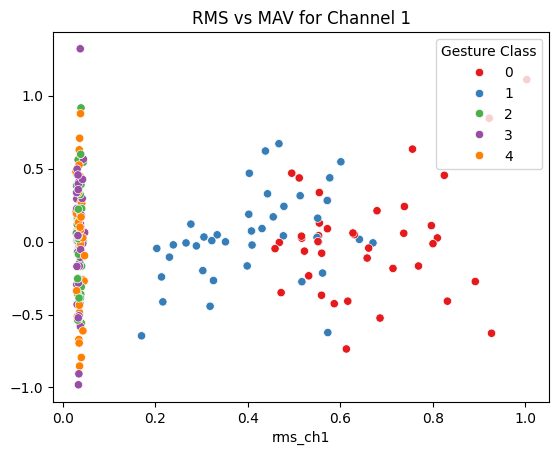

In [434]:
scatter = sns.scatterplot(data=x_train_df, x='rms_ch1', y=mvc_signals[2][:, 1], hue='label', palette='Set1')
scatter.set_title("RMS vs MAV for Channel 1")
plt.legend(title='Gesture Class')

In [435]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm1 = SVC(kernel='rbf', C=0.1, gamma='scale', random_state=42)
svm1.fit(X_train_scaled, y_train)
svm1.get_params()


{'C': 0.1,
 'break_ties': False,
 'cache_size': 200,
 'class_weight': None,
 'coef0': 0.0,
 'decision_function_shape': 'ovr',
 'degree': 3,
 'gamma': 'scale',
 'kernel': 'rbf',
 'max_iter': -1,
 'probability': False,
 'random_state': 42,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}

In [436]:
from sklearn.model_selection import GridSearchCV
GSC= GridSearchCV(estimator=SVC(random_state=42),
                 param_grid={'C': [0.1, 1, 10], 'gamma': ['scale', 'auto']},
                 cv=5, n_jobs=-1)

In [437]:
from sklearn.metrics import classification_report
svm1_predictions = svm1.predict(X_test_scaled)
print (classification_report(y_test, svm1_predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        10
           3       1.00      1.00      1.00        10
           4       1.00      1.00      1.00        10

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



In [438]:
datasets = {
    "mvc":   (mvc_signals,   mvc_labels),
    "dof1":  (dof1_signals,  dof1_labels),
    "ndof":  (ndof_signals,  ndof_labels),
    "pr":    (pr_signals,    pr_labels),
}

for name, (signals, labels) in datasets.items():
    print(f"{name}:")
    print(f"  signals shape : {signals.shape}")
    print(f"  labels shape  : {labels.shape}")
    print(f"  label range   : {labels.min()} → {labels.max()}")
    print(f"  unique labels : {np.unique(labels)}")
    print()

mvc:
  signals shape : (250, 200, 14)
  labels shape  : (250,)
  label range   : 0 → 4
  unique labels : [0 1 2 3 4]

dof1:
  signals shape : (250, 200, 14)
  labels shape  : (250,)
  label range   : 0 → 4
  unique labels : [0 1 2 3 4]

ndof:
  signals shape : (1000, 200, 14)
  labels shape  : (1000,)
  label range   : 0 → 19
  unique labels : [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]

pr:
  signals shape : (1700, 200, 14)
  labels shape  : (1700,)
  label range   : 0 → 33
  unique labels : [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33]



In [439]:
print(ndof_signals.shape)  # should be (1000, 200, 14)
print(ndof_labels.shape)   # should be (1000,)
print(np.unique(ndof_labels))  # 0 through 19

(1000, 200, 14)
(1000,)
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]


In [440]:
X_ndof = np.array([extract_features(window) for window in ndof_signals])
y_ndof = ndof_labels

print(X_ndof.shape)
print(y_ndof.shape)

(1000, 56)
(1000,)


In [441]:
from sklearn.model_selection import train_test_split

X_train_ndof, X_test_ndof, y_train_ndof, y_test_ndof = train_test_split(
    X_ndof, y_ndof,
    test_size=0.2,
    random_state=42,
    stratify=y_ndof
)

print(X_train_ndof.shape)  # 800 windows for training
print(X_test_ndof.shape)   # 200 windows for testing

(800, 56)
(200, 56)


In [442]:
from sklearn.preprocessing import StandardScaler

scaler_ndof = StandardScaler()
X_train_ndof_scaled = scaler_ndof.fit_transform(X_train_ndof)
X_test_ndof_scaled = scaler_ndof.transform(X_test_ndof)

In [443]:
from sklearn.svm import SVC

svm_ndof = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
svm_ndof.fit(X_train_ndof_scaled, y_train_ndof)

print("Training complete.")

Training complete.


In [444]:
from sklearn.metrics import classification_report

y_pred_ndof = svm_ndof.predict(X_test_ndof_scaled)
print(classification_report(y_test_ndof, y_pred_ndof))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.78      0.70      0.74        10
           2       0.82      0.90      0.86        10
           3       0.50      0.50      0.50        10
           4       0.57      0.80      0.67        10
           5       0.67      0.60      0.63        10
           6       0.60      0.60      0.60        10
           7       0.69      0.90      0.78        10
           8       1.00      0.80      0.89        10
           9       0.64      0.70      0.67        10
          10       0.62      0.50      0.56        10
          11       0.58      0.70      0.64        10
          12       0.50      0.40      0.44        10
          13       0.78      0.70      0.74        10
          14       0.90      0.90      0.90        10
          15       0.89      0.80      0.84        10
          16       0.56      0.50      0.53        10
          17       0.86    

In [446]:
# ── AUGMENTATION HELPERS ─────────────────────────────────────────────────────

def augment_batch(X_batch):
    """Apply random augmentations to a batch of (batch, 200, 14) signals."""
    aug = X_batch.copy()
    batch_size = aug.shape[0]

    # 1. Amplitude scaling — random per sample
    scale = np.random.uniform(0.8, 1.2, size=(batch_size, 1, 1))
    aug *= scale

    # 2. Gaussian noise injection
    aug += np.random.randn(*aug.shape) * 0.05

    # 3. Time shift — roll signal along timestep axis
    shifts = np.random.randint(-20, 20, size=batch_size)
    for i, s in enumerate(shifts):
        aug[i] = np.roll(aug[i], s, axis=0)

    # 4. Channel dropout — zero out 1 random channel per sample
    drop_ch = np.random.randint(0, 14, size=batch_size)
    for i, ch in enumerate(drop_ch):
        aug[i, :, ch] = 0.0

    return aug


# ── CUSTOM DATA GENERATOR ─────────────────────────────────────────────────────

class AugmentedEMGGenerator(tf.keras.utils.Sequence):
    def __init__(self, X, y, batch_size=32, augment=True):
        self.X         = X
        self.y         = y
        self.batch_size = batch_size
        self.augment   = augment
        self.indices   = np.arange(len(X))

    def __len__(self):
        return int(np.ceil(len(self.X) / self.batch_size))

    def __getitem__(self, idx):
        batch_idx = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        X_batch   = self.X[batch_idx]
        y_batch   = self.y[batch_idx]
        if self.augment:
            X_batch = augment_batch(X_batch)
        return X_batch, y_batch

    def on_epoch_end(self):
        np.random.shuffle(self.indices)  # reshuffle each epoch


# ── REPLACE model.fit() WITH THIS ────────────────────────────────────────────

# Split off validation manually (no augmentation on val)
val_split = int(0.15 * len(X_train))
X_val, y_val     = X_train[:val_split], y_train[:val_split]
X_tr,  y_tr      = X_train[val_split:], y_train[val_split:]

train_gen = AugmentedEMGGenerator(X_tr,  y_tr,  batch_size=32, augment=True)
val_gen   = AugmentedEMGGenerator(X_val, y_val, batch_size=32, augment=False)

print("\n── CNN+LSTM Training (with augmentation) ──")
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=80,                         # more epochs since augmentation slows convergence
    callbacks=cb,
    verbose=1
)


── CNN+LSTM Training (with augmentation) ──
Epoch 1/80
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 171ms/step - accuracy: 0.5574 - loss: 1.4246 - val_accuracy: 0.7250 - val_loss: 0.6275 - learning_rate: 1.2500e-04
Epoch 2/80
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 122ms/step - accuracy: 0.5588 - loss: 1.1836 - val_accuracy: 0.7167 - val_loss: 0.6359 - learning_rate: 1.2500e-04
Epoch 3/80
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 119ms/step - accuracy: 0.5691 - loss: 1.1786 - val_accuracy: 0.7083 - val_loss: 0.6393 - learning_rate: 1.2500e-04
Epoch 4/80
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 124ms/step - accuracy: 0.5500 - loss: 1.1611 - val_accuracy: 0.7083 - val_loss: 0.6533 - learning_rate: 1.2500e-04
Epoch 5/80
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 130ms/step - accuracy: 0.6029 - loss: 1.0387 - val_accuracy: 0.6917 - val_loss: 0.6483 - learning_rate: 1.2500e-04
Epoch 6/80
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 122ms/step - accuracy: 0.5809 - loss: 1.0274 - val_accuracy: 0.7000 - val_loss: 0.6557 - learning_rate: 1.2500e-04
Epoch 7/80
22/22 ━

Signals shape : (1000, 200, 14)
Labels shape  : (1000,)
Unique classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
Number of classes: 20

Train: (800, 200, 14) | Test: (200, 200, 14)

── SVM Baseline ──
SVM Accuracy: 0.7200


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 200, 14)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 200, 64)        │         4,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 200, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 100, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 100, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 20)             │         2,580 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 221,908 (866.83 KB)

 Trainable params: 221,524 (865.33 KB)

 Non-trainable params: 384 (1.50 KB)


── CNN+LSTM Training ──
Epoch 1/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 15s 211ms/step - accuracy: 0.1324 - loss: 2.8166 - val_accuracy: 0.1667 - val_loss: 2.7068 - learning_rate: 0.0010
Epoch 2/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 141ms/step - accuracy: 0.2500 - loss: 2.1926 - val_accuracy: 0.2083 - val_loss: 2.2862 - learning_rate: 0.0010
Epoch 3/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 118ms/step - accuracy: 0.2588 - loss: 1.7753 - val_accuracy: 0.2917 - val_loss: 2.2674 - learning_rate: 0.0010
Epoch 4/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 144ms/step - accuracy: 0.3485 - loss: 1.5166 - val_accuracy: 0.2333 - val_loss: 2.2617 - learning_rate: 0.0010
Epoch 5/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 123ms/step - accuracy: 0.3235 - loss: 1.4531 - val_accuracy: 0.2167 - val_loss: 2.1856 - learning_rate: 0.0010
Epoch 6/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 132ms/step - accuracy: 0.3250 - loss: 1.4076 - val_accuracy: 0.2333 - val_loss: 2.1482 - learning_rate: 0.0010
Epoch 7/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 126ms/step - accuracy

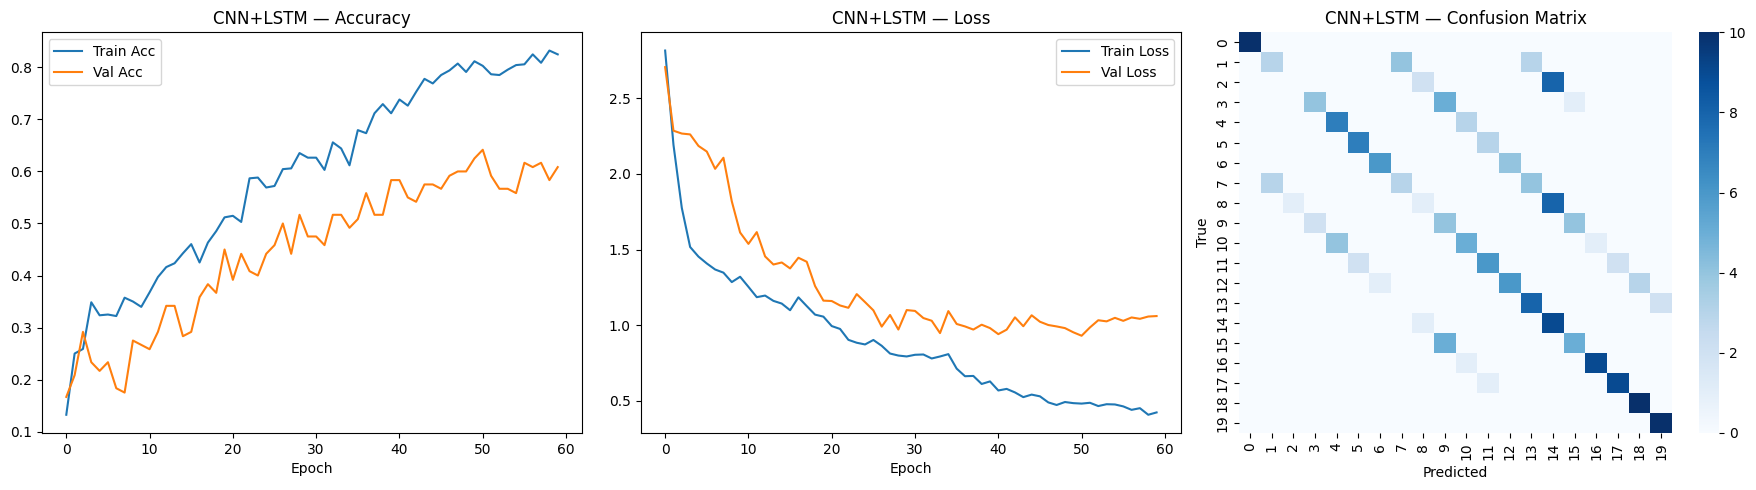

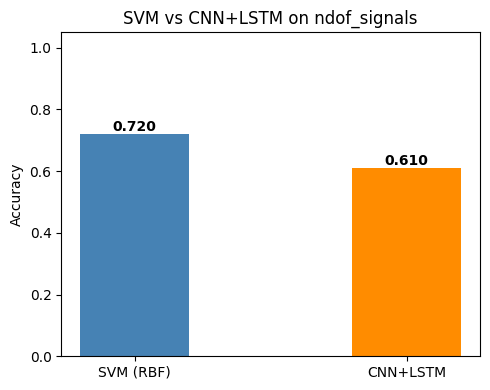

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC


# ── 1. LOAD DATA ─────────────────────────────────────────────────────────────

ndof_signals = np.load("dummy_ninapro_data\\ndof_signals.npy")  # (N, 200, 14)
ndof_labels  = np.load("dummy_ninapro_data\\ndof_labels.npy")   # (N,)

print(f"Signals shape : {ndof_signals.shape}")
print(f"Labels shape  : {ndof_labels.shape}")
print(f"Unique classes: {np.unique(ndof_labels)}")

X = ndof_signals  # (N, 200, 14)
y = ndof_labels

# Encode labels to 0-indexed integers
le = LabelEncoder()
y_enc = le.fit_transform(y)
n_classes = len(np.unique(y_enc))
print(f"Number of classes: {n_classes}")

# ── 2. TRAIN / TEST SPLIT ─────────────────────────────────────────────────────

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)
print(f"\nTrain: {X_train.shape} | Test: {X_test.shape}")

# ── 3. SVM BASELINE ───────────────────────────────────────────────────────────

def extract_features(X):
    """MAV, RMS, WL, ZC per channel → flat vector."""
    feats = []
    for win in X:
        mav = np.mean(np.abs(win), axis=0)
        rms = np.sqrt(np.mean(win**2, axis=0))
        wl  = np.sum(np.abs(np.diff(win, axis=0)), axis=0)
        zc  = np.sum(((win[:-1] * win[1:]) < 0).astype(float), axis=0)
        feats.append(np.concatenate([mav, rms, wl, zc]))
    return np.array(feats)

print("\n── SVM Baseline ──")
X_train_feat = extract_features(X_train)
X_test_feat  = extract_features(X_test)

scaler = StandardScaler()
X_train_feat = scaler.fit_transform(X_train_feat)
X_test_feat  = scaler.transform(X_test_feat)

svm = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm.fit(X_train_feat, y_train)
svm_preds = svm.predict(X_test_feat)
svm_acc = accuracy_score(y_test, svm_preds)
print(f"SVM Accuracy: {svm_acc:.4f}")

# ── 4. CNN + LSTM MODEL ───────────────────────────────────────────────────────
# Input shape: (200, 14) — 200 timesteps, 14 channels

def build_cnn_lstm(input_shape, n_classes):
    inp = layers.Input(shape=input_shape)  # (200, 14)

    # Block 1: local temporal patterns
    x = layers.Conv1D(64, kernel_size=5, padding='same', activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)   # → (100, 64)
    x = layers.Dropout(0.3)(x)

    # Block 2: higher-level patterns
    x = layers.Conv1D(128, kernel_size=3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)   # → (50, 128)
    x = layers.Dropout(0.3)(x)

    # LSTM: sequential memory across compressed timesteps
    x = layers.LSTM(128, return_sequences=True)(x)
    x = layers.Dropout(0.3)(x)
    x = layers.LSTM(64)(x)
    x = layers.Dropout(0.3)(x)

    # Classifier head
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(n_classes, activation='softmax')(x)

    model = models.Model(inp, out)
    return model

model = build_cnn_lstm(input_shape=(200, 14), n_classes=n_classes)
model.summary()

# ── 5. COMPILE & TRAIN ────────────────────────────────────────────────────────

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cb = [
    callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)
]

print("\n── CNN+LSTM Training ──")
history = model.fit(
    X_train, y_train,
    epochs=60,
    batch_size=32,
    validation_split=0.15,
    callbacks=cb,
    verbose=1
)

# ── 6. EVALUATE ───────────────────────────────────────────────────────────────

cnn_preds = np.argmax(model.predict(X_test), axis=1)
cnn_acc   = accuracy_score(y_test, cnn_preds)

print(f"\n{'='*40}")
print(f"SVM  Accuracy : {svm_acc:.4f}")
print(f"CNN+LSTM Accuracy: {cnn_acc:.4f}")
print(f"Improvement   : +{cnn_acc - svm_acc:.4f}")
print(f"{'='*40}")

print("\nCNN+LSTM Classification Report:")
print(classification_report(y_test, cnn_preds,
                             target_names=[f"G{i}" for i in le.classes_]))

# ── 7. PLOTS ──────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Training curves
axes[0].plot(history.history['accuracy'],     label='Train Acc')
axes[0].plot(history.history['val_accuracy'], label='Val Acc')
axes[0].set_title('CNN+LSTM — Accuracy')
axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('CNN+LSTM — Loss')
axes[1].set_xlabel('Epoch'); axes[1].legend()

# Confusion matrix
cm = confusion_matrix(y_test, cnn_preds)
sns.heatmap(cm, ax=axes[2], cmap='Blues', fmt='d',
            xticklabels=le.classes_, yticklabels=le.classes_)
axes[2].set_title('CNN+LSTM — Confusion Matrix')
axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('True')

plt.tight_layout()
plt.savefig("cnn_lstm_results.png", dpi=150)
plt.show()

# Bar comparison
fig2, ax = plt.subplots(figsize=(5, 4))
ax.bar(['SVM (RBF)', 'CNN+LSTM'], [svm_acc, cnn_acc],
       color=['steelblue', 'darkorange'], width=0.4)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Accuracy')
ax.set_title('SVM vs CNN+LSTM on ndof_signals')
for i, v in enumerate([svm_acc, cnn_acc]):
    ax.text(i, v + 0.01, f"{v:.3f}", ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig("svm_vs_cnn_comparison.png", dpi=150)
plt.show()